In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import nltk
nltk.download('punkt')      # tokenizer
nltk.download('stopwords')  # english stopwords
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/elena/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/elena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/elena/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
path = r"/home/elena/emcomm/emcomm_captions/0th_fix_metric_test_predictions.csv"

In [3]:
df = pd.read_csv(path)
df

,hypothesis,reference
0,a man in a red shirt and black shorts playing ...,a man that is jumping in the air with a skateb...
1,"a kitchen with a stove, microwave, and a micro...",a kitchen filled with a wooden cabinet and a l...
2,a man in a red shirt and black shorts playing ...,a young boy balancing himself on his skateboard.
3,a computer desk with a laptop and a monitor on...,a wall displaying an assorted collection of di...
4,a man is riding a wave on a surfboard......,a cow is standing in sand by some water.
...,...,...
3495,a man and a woman are sitting at a table......,men ordering food from a small outside restaur...
3496,a cat sitting on a chair in a room.......,a white sink with a black cabinet underneath it.
3497,a zebra standing in a grassy field next to a t...,a couple of birds are standing on a branch
3498,a large jetliner flying through a cloudy sky.....,a little plane flying above a lake full of boats


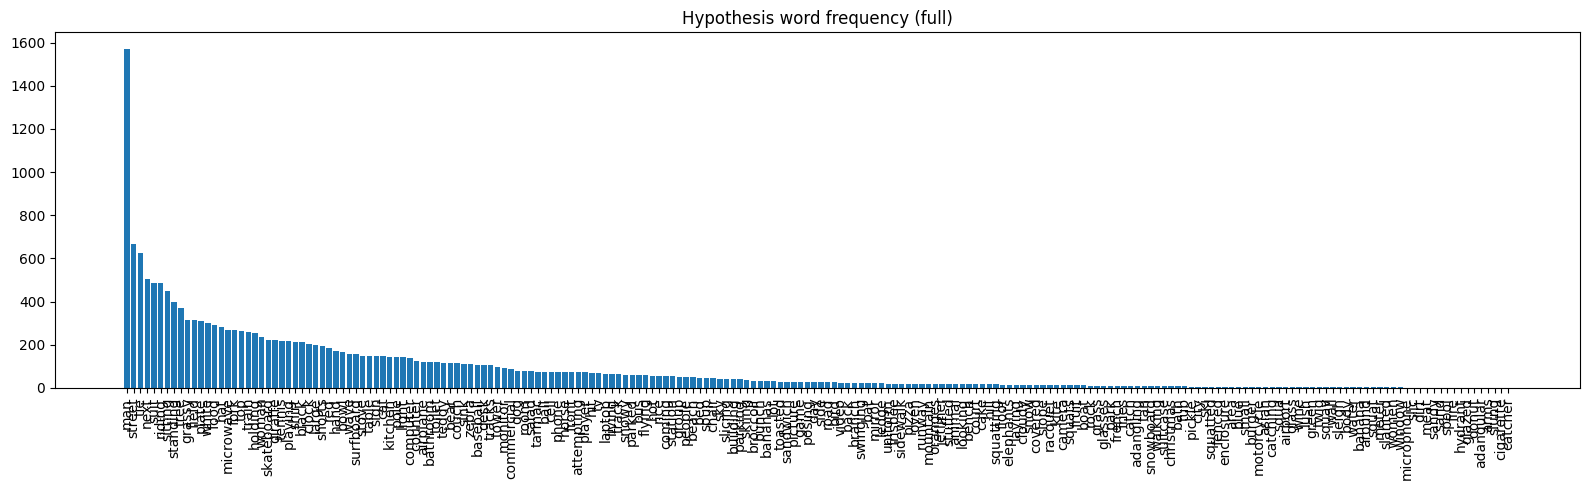

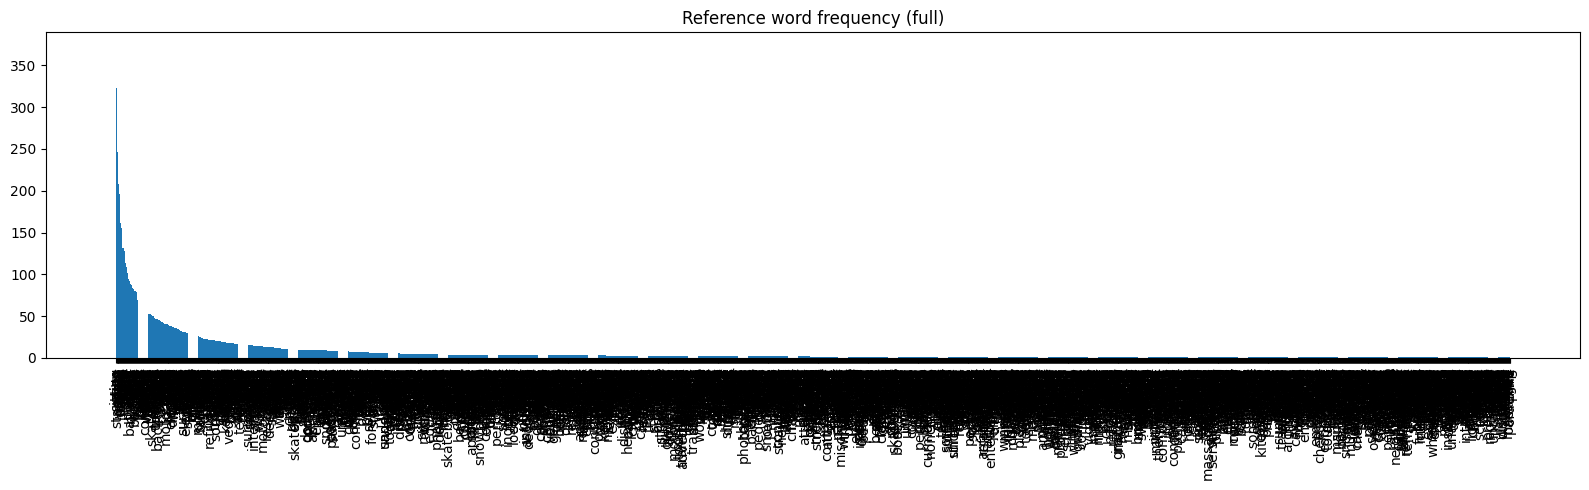

In [4]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import string

# prepare stop‑words set once
stop_words = set(stopwords.words('english'))

def tokenize_and_clean(text):
    toks = word_tokenize(text.lower())
    # keep only alphabetic tokens and drop stopwords
    return [t for t in toks if t.isalpha() and t not in stop_words]

# add token lists to the dataframe
df['hyp_tokens'] = df['hypothesis'].apply(tokenize_and_clean)
df['ref_tokens'] = df['reference'].apply(tokenize_and_clean)

# flatten lists and count frequencies
hyp_counter = Counter(w for toks in df['hyp_tokens'] for w in toks)
ref_counter = Counter(w for toks in df['ref_tokens'] for w in toks)

# convert to dataframes sorted by frequency
hyp_df = pd.DataFrame(hyp_counter.most_common(), columns=['word', 'count'])
ref_df = pd.DataFrame(ref_counter.most_common(), columns=['word', 'count'])

# --- plot full distributions -----------------------------------------------
plt.figure(figsize=(16,5))
plt.bar(hyp_df['word'], hyp_df['count'])
plt.title('Hypothesis word frequency (full)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,5))
plt.bar(ref_df['word'], ref_df['count'])
plt.title('Reference word frequency (full)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,

    "axes.titlesize": 11,
    "axes.labelsize": 10,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "legend.fontsize": 9,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.7,

    "lines.linewidth": 1.5,

    "savefig.bbox": "tight",
})

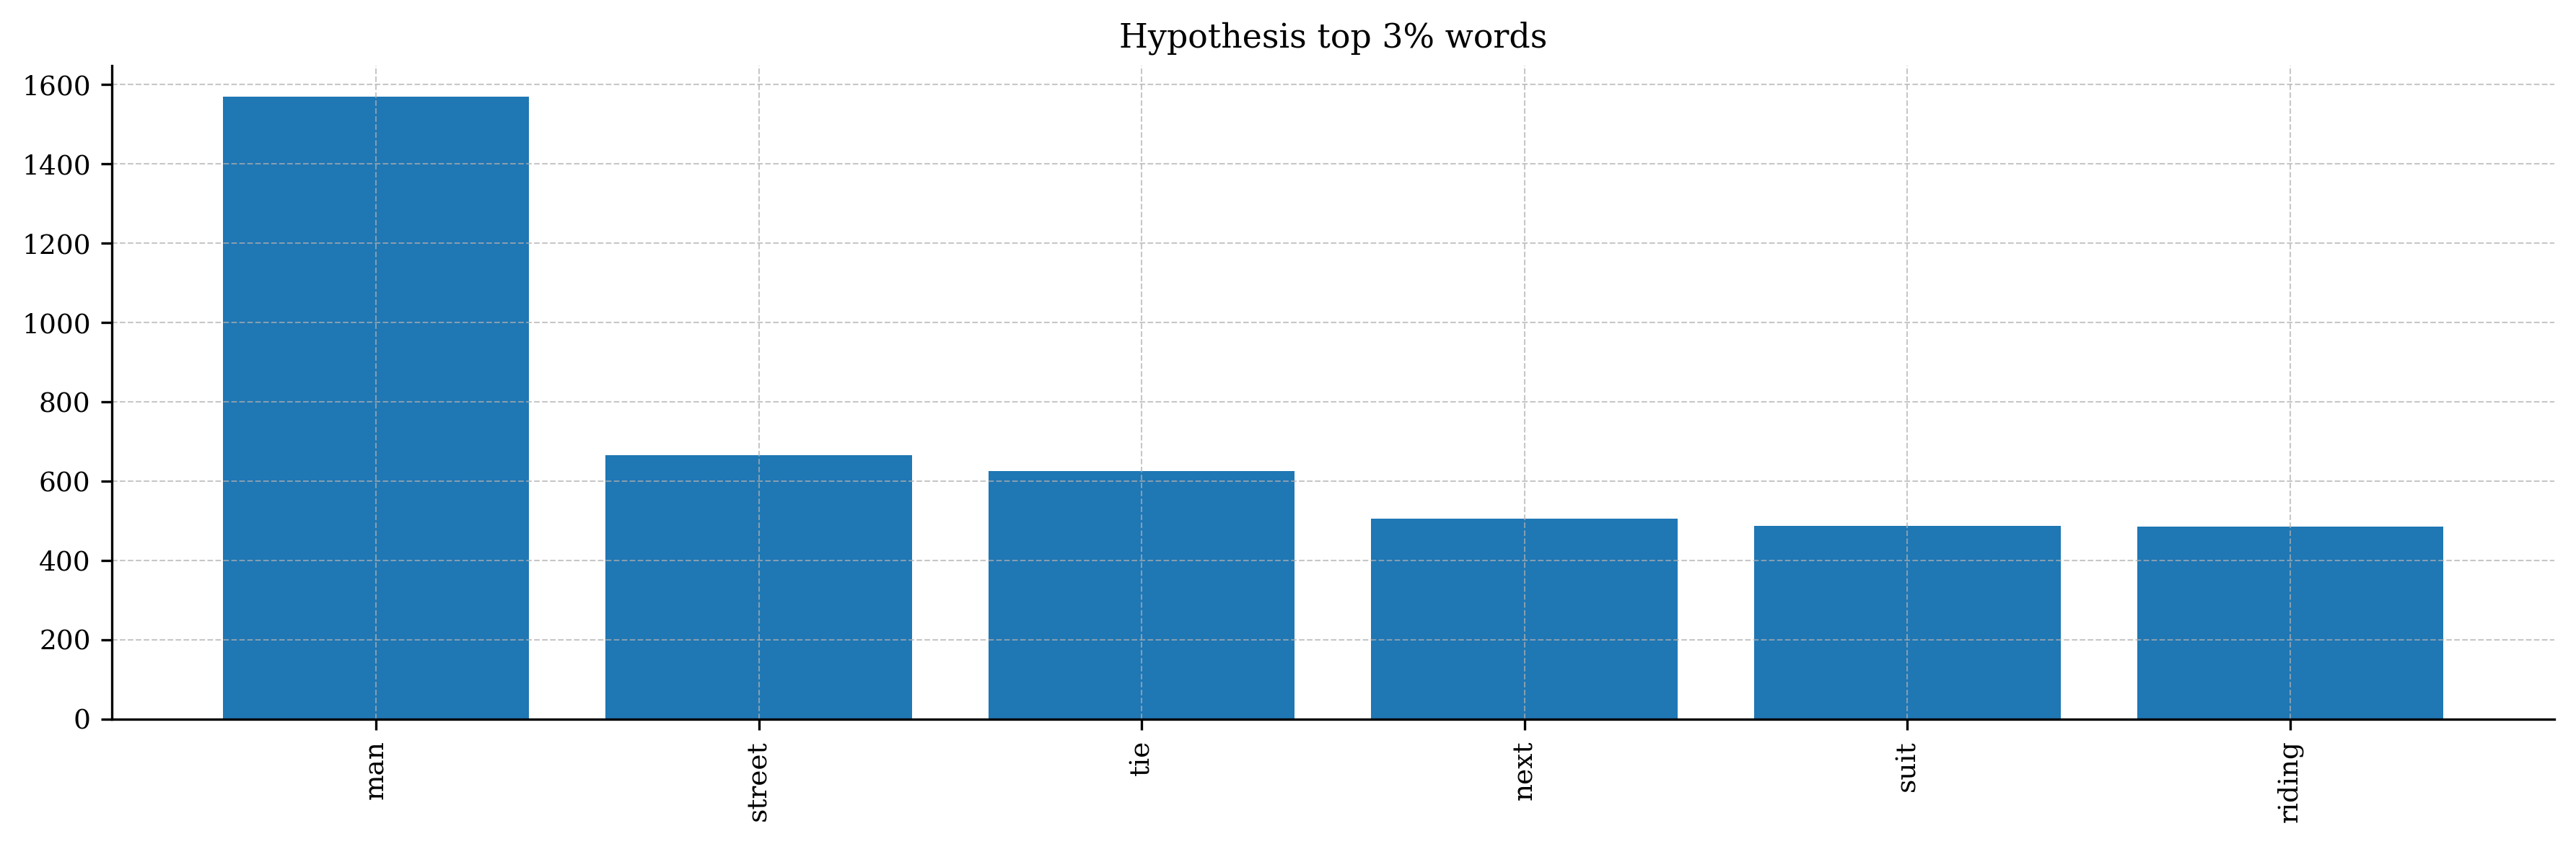

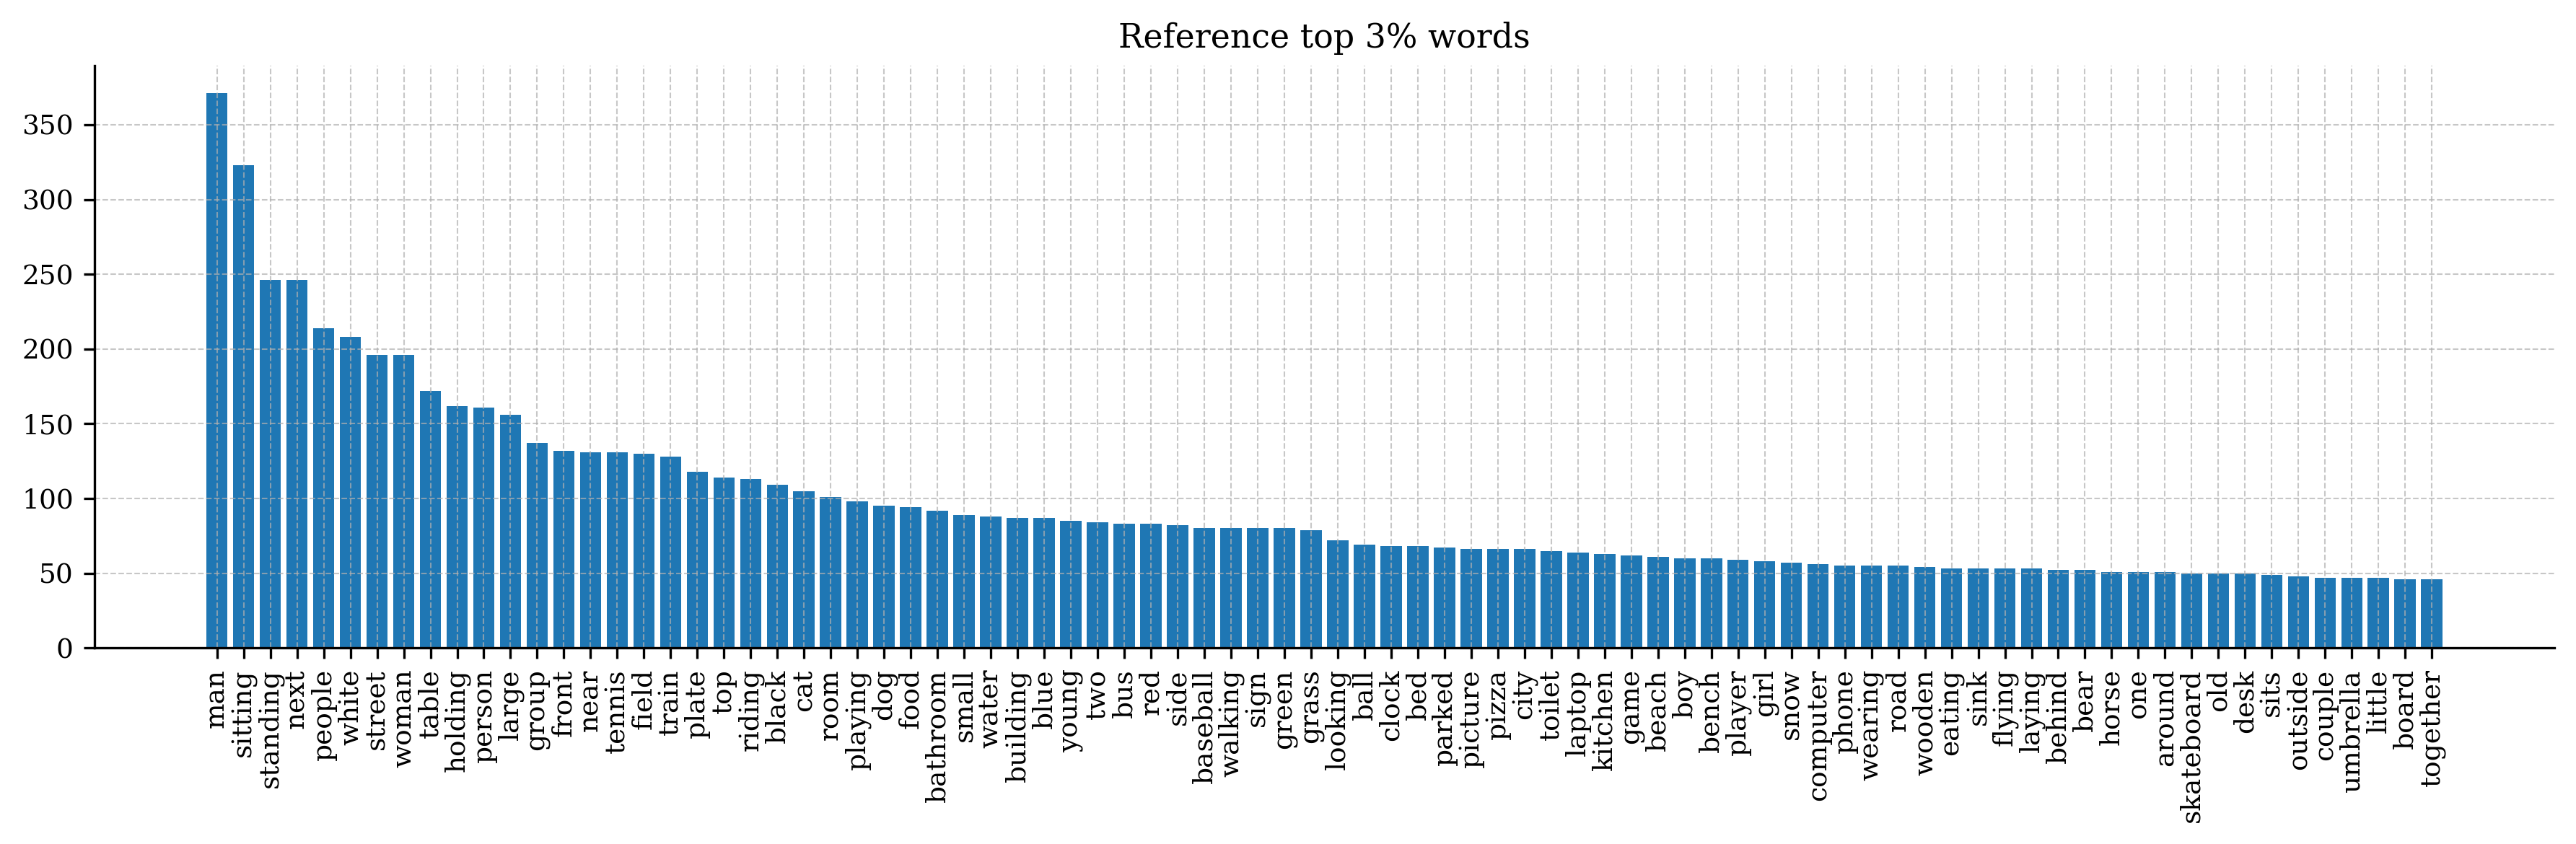

In [10]:
percent = 3
n_hyp = int(len(hyp_df) * 0.01*percent)
n_ref = int(len(ref_df) * 0.01*percent)

hyp_top = hyp_df.iloc[:n_hyp]
ref_top = ref_df.iloc[:n_ref]

plt.figure(figsize=(12,4))
plt.bar(hyp_top['word'], hyp_top['count'])
plt.title(f'Hypothesis top {percent}% words')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.bar(ref_top['word'], ref_top['count'])
plt.title(f'Reference top {percent}% words')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

19477
17831


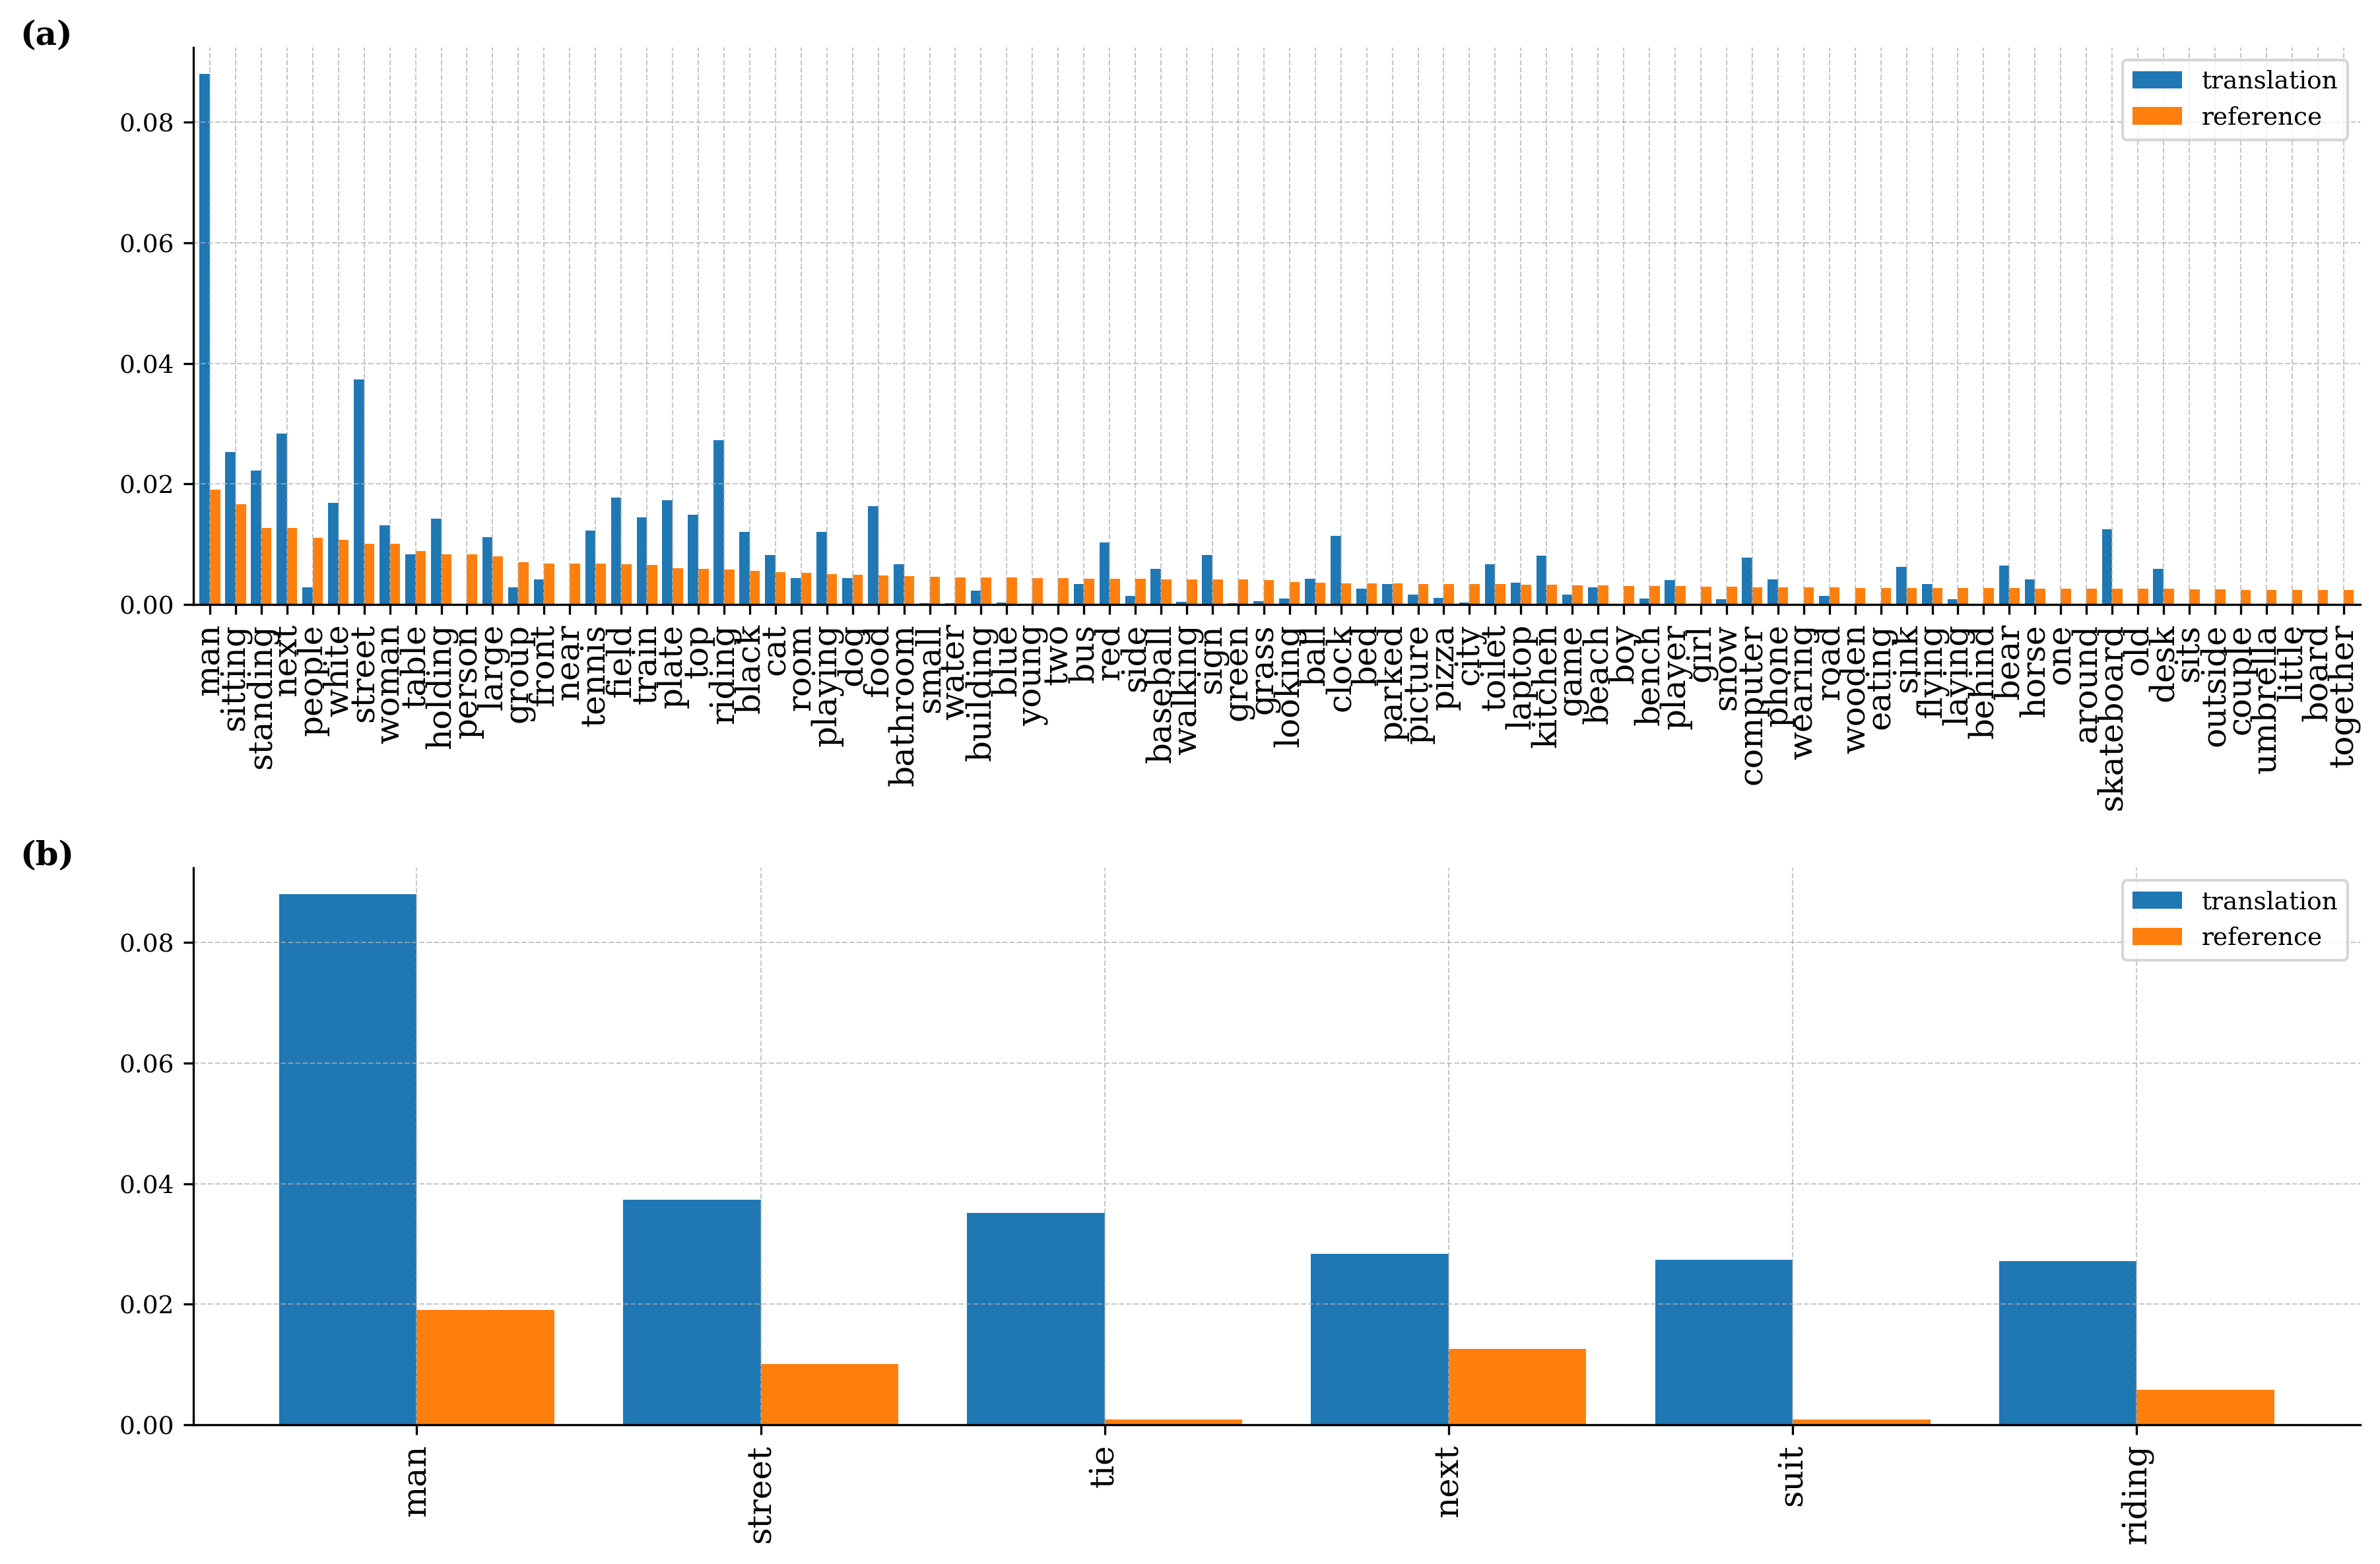

In [11]:
# total corpus sizes
total_hyp_tokens = sum(hyp_counter.values())
total_ref_tokens = sum(ref_counter.values())

# select top n% words
ref_top_words = ref_df.iloc[:n_ref]['word']
hyp_top_words = hyp_df.iloc[:n_hyp]['word']
print(total_ref_tokens)
print(total_hyp_tokens)

# helper: build dataframe with relative frequencies
def build_rel_freq_df(words, hyp_ctr, ref_ctr, total_hyp, total_ref):
    data = {
        "word": words,
        "translation": [hyp_ctr.get(w, 0) / total_hyp for w in words],
        "reference": [ref_ctr.get(w, 0) / total_ref for w in words],
    }
    return pd.DataFrame(data).set_index("word")

# --- Top % reference words ---
df_refwords = build_rel_freq_df(
    ref_top_words,
    hyp_counter,
    ref_counter,
    total_hyp_tokens,
    total_ref_tokens,
)

# df_refwords.plot(kind="bar", figsize=(12, 4), width=0.8)
# plt.title(f"Relative frequency of top {percent}% reference words")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

# --- Top % hypothesis words ---
df_hypwords = build_rel_freq_df(
    hyp_top_words,
    hyp_counter,
    ref_counter,
    total_hyp_tokens,
    total_ref_tokens,
)

# df_hypwords.plot(kind="bar", figsize=(12, 4), width=0.8)
# plt.title(f"Relative frequency of top {percent}% hypothesis words")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Top % reference words ---
df_refwords.plot(kind="bar", ax=axes[0], width=0.8)
# axes[0].set_title(f"Relative frequency of top {percent}% reference words")
axes[0].tick_params(axis="x", rotation=90)

# (a)
axes[0].text(
    -0.08, 1.05, "(a)",
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

# --- Top % hypothesis words ---
df_hypwords.plot(kind="bar", ax=axes[1], width=0.8)
# axes[1].set_title(f"Relative frequency of top {percent}% hypothesis words")
axes[1].tick_params(axis="x", rotation=90)

# (b)
axes[1].text(
    -0.08, 1.05, "(b)",
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[0].tick_params(axis="x", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)
plt.tight_layout()
plt.savefig("word_freq_comparison.pdf", format='pdf', dpi=300)
plt.show()